In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import glob
import json
import _utils

In [2]:
import seaborn as sns

In [3]:
import warnings # To suppress some warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [4]:
file_dir = "../mnt_processed_data/"

In [5]:
common_mask = xr.open_dataset(file_dir+"common_land_mask.nc")
def model_mask(ds):
    return(xr.where(common_mask.__xarray_dataarray_variable__ == 1, ds, np.nan))

combined_mask_dat = xr.open_dataset(file_dir+"combined_gauge_model_mask.nc")
def combined_mask(ds):
    return(xr.where(combined_mask_dat.__xarray_dataarray_variable__ >= 2, ds, np.nan))

In [6]:
N = (common_mask.__xarray_dataarray_variable__ == 1).sum().values
N_sub = (combined_mask_dat.__xarray_dataarray_variable__ >= 2).sum().values
print("N:", N, " N_sub:", N_sub)

N: 693  N_sub: 308


In [7]:
mon_pos_trends = pd.read_csv(file_dir+"model_positive_mon-p095_trends.csv", index_col=0)
day_pos_trends = pd.read_csv(file_dir+"model_positive_rx1day_trends.csv", index_col=0)

mon_obs_pos_trends = pd.read_csv(file_dir+"obs_positive_monthly_trends.csv", index_col=0)
day_obs_pos_trends = pd.read_csv(file_dir+"obs_positive_rx1day_trends.csv", index_col=0)

In [8]:
day_pos_trends["length"] = day_pos_trends["end_year"] - day_pos_trends["start_year"] +1
day_pos_trends["pos_percent"] = day_pos_trends["pos_trends_gaugemask"]/N_sub

day_obs_pos_trends["length"] = day_obs_pos_trends["end_year"] - day_obs_pos_trends["start_year"] +1
day_obs_pos_trends["pos_percent"] = day_obs_pos_trends["pos_trends_gaugemask"]/N_sub

In [9]:
mon_pos_trends["length"] = mon_pos_trends["end_year"] - mon_pos_trends["start_year"] +1
mon_pos_trends["pos_percent"] = mon_pos_trends["pos_trends_gaugemask"]/N_sub

mon_obs_pos_trends["length"] = mon_obs_pos_trends["end_year"] - mon_obs_pos_trends["start_year"] +1
mon_obs_pos_trends["pos_percent"] = mon_obs_pos_trends["pos_trends_gaugemask"]/N_sub

In [10]:
day_time_series_data = pd.read_csv(file_dir+"time_series_summary_rx1day.csv", index_col=0)
day_time_series_data["percent_above"] = day_time_series_data[["ecdf_pos_1_mask", "ecdf_neg_1_mask"]].sum(axis=1)/N_sub*100
day_time_series_data["percent_below"] = day_time_series_data[["ecdf_neg_0_mask", "ecdf_pos_0_mask"]].sum(axis=1)/N_sub*100
day_time_series_data["length"] = day_time_series_data["end_year"] - day_time_series_data["start_year"] + 1
day_time_series_data["percent_outside"] = day_time_series_data[["ecdf_pos_1_mask", "ecdf_pos_0_mask", "ecdf_neg_0_mask", "ecdf_neg_1_mask"]].sum(axis = 1)/N_sub*100

In [11]:
mon_time_series_data = pd.read_csv(file_dir+"time_series_summary_mon-p095.csv", index_col=0)
mon_time_series_data["percent_above"] = mon_time_series_data[["ecdf_pos_1_mask", "ecdf_neg_1_mask"]].sum(axis=1)/N_sub*100
mon_time_series_data["percent_below"] = mon_time_series_data[["ecdf_neg_0_mask", "ecdf_pos_0_mask"]].sum(axis=1)/N_sub*100
mon_time_series_data["length"] = mon_time_series_data["end_year"] - mon_time_series_data["start_year"] + 1
mon_time_series_data["percent_outside"] = mon_time_series_data[["ecdf_pos_1_mask", "ecdf_pos_0_mask", "ecdf_neg_0_mask", "ecdf_neg_1_mask"]].sum(axis = 1)/N_sub*100

In [12]:
a = mon_obs_pos_trends.loc[(mon_obs_pos_trends.length == 42) & (mon_obs_pos_trends.start_year % 5 == 4)]
a_mod = mon_pos_trends.loc[(mon_pos_trends.length == 42) & (mon_pos_trends.start_year % 5 == 4) & (mon_pos_trends.model == "cmip")]
b = day_obs_pos_trends.loc[(day_obs_pos_trends.length == 42) & (day_obs_pos_trends.start_year % 5 == 4)]
b_mod = day_pos_trends.loc[(day_pos_trends.length == 42) & (day_pos_trends.start_year % 5 == 4) & (day_pos_trends.model == "cmip")]

c = mon_time_series_data.loc[(mon_time_series_data.length == 42) & (mon_time_series_data.start_year % 5 == 4)]
d = day_time_series_data.loc[(day_time_series_data.length == 42) & (day_time_series_data.start_year % 5 == 4)]

e = mon_obs_pos_trends.loc[(mon_obs_pos_trends.end_year == 2020) & (mon_obs_pos_trends.length % 5 == 2)]
e_mod = mon_pos_trends.loc[(mon_pos_trends.end_year == 2020) & (mon_pos_trends.length % 5 == 2) & (mon_pos_trends.model == "cmip")]
f = day_obs_pos_trends.loc[(day_obs_pos_trends.end_year == 2016) & (day_obs_pos_trends.length % 5 == 2)]
f_mod = day_pos_trends.loc[(day_pos_trends.end_year == 2016) & (day_pos_trends.length % 5 == 2) & (day_pos_trends.model == "cmip")]

g = mon_time_series_data.loc[(mon_time_series_data.end_year == 2020) & (mon_time_series_data.length % 5 == 2)]
h = day_time_series_data.loc[(day_time_series_data.end_year == 2016) & (day_time_series_data.length % 5 == 2)]

In [13]:
a

,start_year,end_year,obs,pos_trends,pos_trends_gaugemask,length,pos_percent
0,1934,1975,gpcc,429,185,42,0.600649
0,1939,1980,gpcc,407,179,42,0.581169
0,1944,1985,gpcc,408,192,42,0.623377
0,1949,1990,gpcc,370,179,42,0.581169
0,1954,1995,gpcc,341,176,42,0.571429
0,1959,2000,gpcc,365,185,42,0.600649
0,1964,2005,gpcc,347,164,42,0.532468
0,1969,2010,gpcc,388,173,42,0.561688
0,1974,2015,gpcc,361,164,42,0.532468
0,1979,2020,gpcc,389,169,42,0.548701


In [14]:
N_sub

array(308)

In [15]:
mon_time_series_data

,start_year,end_year,obs,model,ecdf_pos_1,ecdf_pos_0,ecdf_neg_1,ecdf_neg_0,ecdf_pos_1_mask,ecdf_pos_0_mask,ecdf_neg_1_mask,ecdf_neg_0_mask,percent_above,percent_below,length,percent_outside
0,1930,1960,gpcc,cmip-sub,62,0,0,14,18,0,0,7,5.844156,2.272727,31,8.116883
0,1930,1960,gpcc,spear,87,0,0,13,21,0,0,8,6.818182,2.597403,31,9.415584
0,1930,1960,gpcc,mesaclip,150,0,0,55,50,0,0,27,16.233766,8.766234,31,25.000000
0,1930,1961,gpcc,cmip-sub,59,0,0,15,15,0,0,8,4.870130,2.597403,32,7.467532
0,1930,1961,gpcc,spear,78,0,0,14,18,0,0,8,5.844156,2.597403,32,8.441558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1990,2020,gpcp,spear,26,0,0,59,5,0,0,30,1.623377,9.740260,31,11.363636
0,1990,2020,gpcp,mesaclip,89,2,0,133,24,0,0,62,7.792208,20.129870,31,27.922078
0,1990,2020,mswep,cmip-sub,12,0,0,50,4,0,0,21,1.298701,6.818182,31,8.116883
0,1990,2020,mswep,spear,18,0,0,67,6,0,0,32,1.948052,10.389610,31,12.337662


In [17]:
ecdf_test_summary = []
for start in np.arange(1934, 1980, 5):
    end=start + 41
    x = pd.read_csv(file_dir+"ecdf/gpcc_cmip-sub_mon-p095_"+str(start)+\
                    "-"+str(end)+"_ecdf_test_gauge_mask.csv", index_col = 0)
    dat = x
    dat["start_year"] = start
    dat["end_year"] = end
    dat["percent_above"] = dat[["pos_ecdf_1", "neg_ecdf_1"]].sum(axis=1)/N_sub*100
    ecdf_test_summary.append(dat)

ecdf_test_summary = pd.concat(ecdf_test_summary)

In [18]:
ecdf_test_summary

,pos_ecdf_0,pos_ecdf_1,pos_trends,neg_ecdf_0,neg_ecdf_1,num_values,start_year,end_year,percent_above
0,0,5,113,12,0,308,1934,1975,1.623377
1,0,7,127,7,0,308,1934,1975,2.272727
2,0,7,138,3,0,308,1934,1975,2.272727
3,0,6,124,6,0,308,1934,1975,1.948052
4,0,14,165,7,0,308,1934,1975,4.545455
...,...,...,...,...,...,...,...,...,...
39,0,6,208,6,0,308,1979,2020,1.948052
40,0,11,210,2,0,308,1979,2020,3.571429
41,0,2,194,3,0,308,1979,2020,0.649351
42,0,8,199,1,0,308,1979,2020,2.597403


[(0.0, 20.0)]

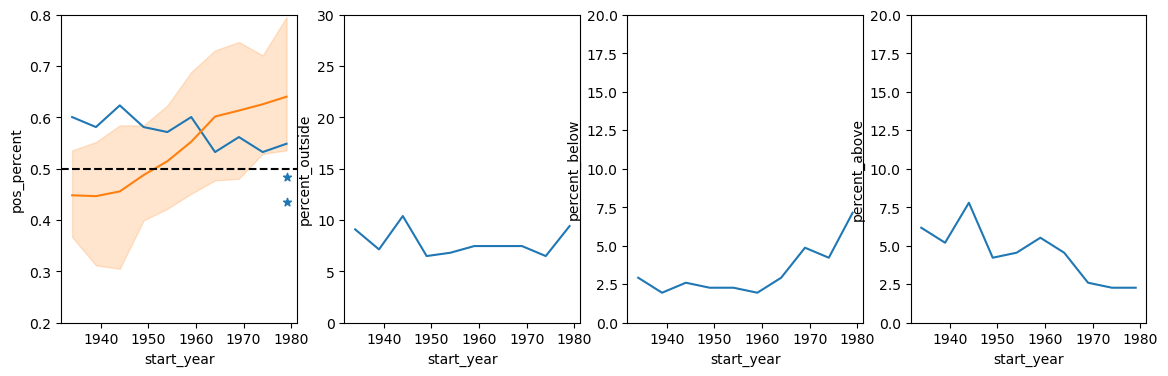

In [19]:
fig, axes = plt.subplots(1, 4, figsize = (14, 4))

## SPLIT BY OBS DATASET!! 
axes[0].plot(a.loc[a.obs == "gpcc"].start_year, a.loc[a.obs == "gpcc"].pos_percent)
sns.lineplot(data = a_mod, x = "start_year", y = "pos_percent", errorbar = ("pi", 100), ax = axes[0])
axes[0].scatter(a.loc[a.obs.isin(["gpcp", "mswep"])].start_year, 
                a.loc[a.obs.isin(["gpcp", "mswep"])].pos_percent, marker = "*")
axes[0].axhline(0.5, linestyle = "--", c = "black")
axes[0].set(ylim = (0.2, 0.8))


sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1])
axes[1].set(ylim = (0, 30))

sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2])
axes[2].set(ylim = (0, 20))

sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3])
axes[3].set(ylim = (0, 20))

[(0.0, 20.0)]

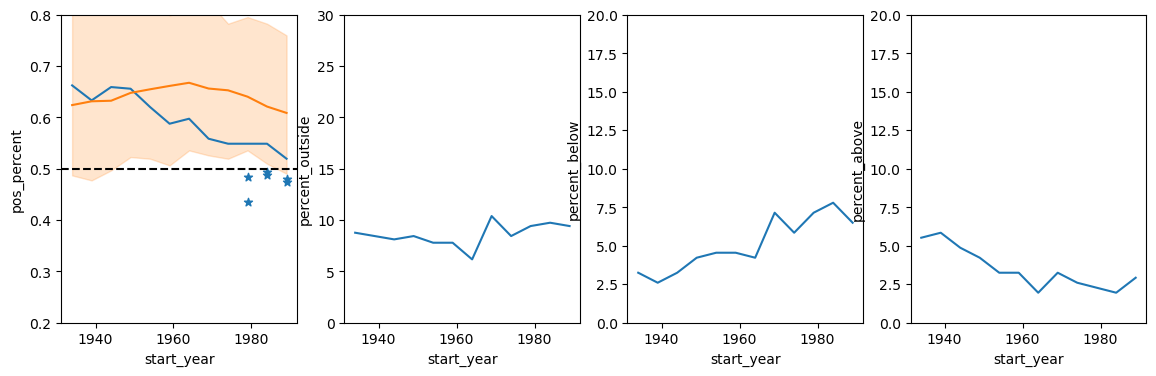

In [20]:
fig, axes = plt.subplots(1, 4, figsize = (14, 4))

## SPLIT BY OBS DATASET!! 
axes[0].plot(e.loc[e.obs == "gpcc"].start_year, e.loc[e.obs == "gpcc"].pos_percent)
sns.lineplot(data = e_mod, x = "start_year", y = "pos_percent", errorbar = ("pi", 100), ax = axes[0])
axes[0].scatter(e.loc[e.obs.isin(["gpcp", "mswep"])].start_year, 
                e.loc[e.obs.isin(["gpcp", "mswep"])].pos_percent, marker = "*")
axes[0].axhline(0.5, linestyle = "--", c = "black")
axes[0].set(ylim = (0.2, 0.8))


sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1])
axes[1].set(ylim = (0, 30))

sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2])
axes[2].set(ylim = (0, 20))

sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3])
axes[3].set(ylim = (0, 20))

[(0.0, 20.0)]

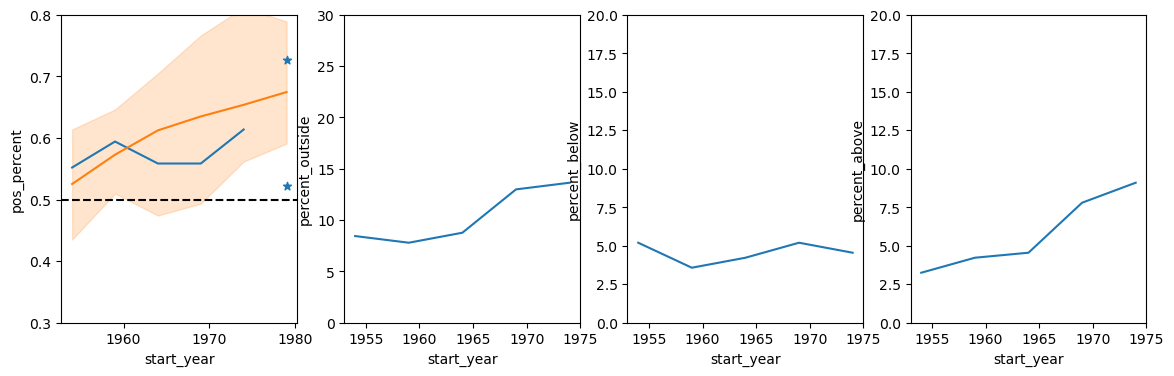

In [21]:
fig, axes = plt.subplots(1, 4, figsize = (14, 4))

## SPLIT BY OBS DATASET!! 
axes[0].plot(b.loc[b.obs == "regen"].start_year, b.loc[b.obs == "regen"].pos_percent)
sns.lineplot(data = b_mod, x = "start_year", y = "pos_percent", errorbar = ("pi", 100), ax = axes[0])
axes[0].scatter(b.loc[b.obs.isin(["cpc", "mswep"])].start_year, 
                b.loc[b.obs.isin(["cpc", "mswep"])].pos_percent, marker = "*")
axes[0].axhline(0.5, linestyle = "--", c = "black")
axes[0].set(ylim = (0.3, 0.8))


sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1])
axes[1].set(ylim = (0, 30))

sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2])
axes[2].set(ylim = (0, 20))

sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3])
axes[3].set(ylim = (0, 20))

[(0.0, 20.0)]

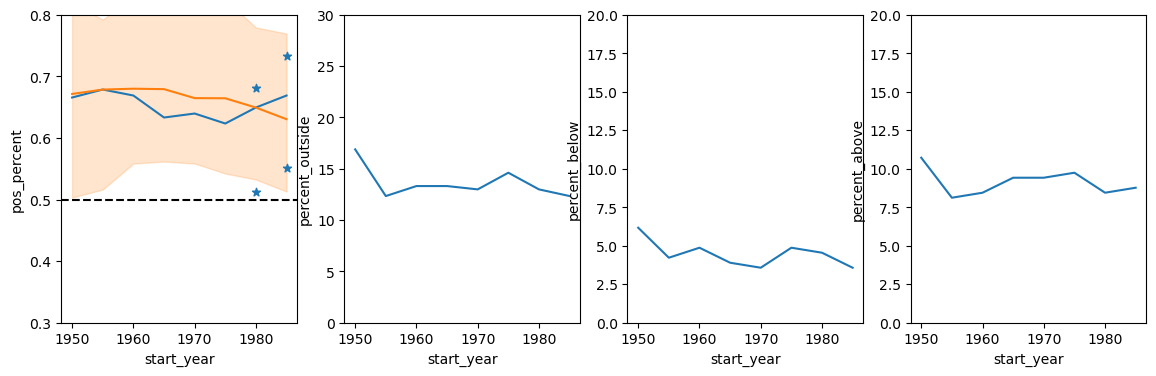

In [22]:
fig, axes = plt.subplots(1, 4, figsize = (14, 4))

## SPLIT BY OBS DATASET!! 
axes[0].plot(f.loc[f.obs == "regen"].start_year, f.loc[f.obs == "regen"].pos_percent)
sns.lineplot(data = f_mod, x = "start_year", y = "pos_percent", errorbar = ("pi", 100), ax = axes[0])
axes[0].scatter(f.loc[f.obs.isin(["cpc", "mswep"])].start_year, 
                f.loc[f.obs.isin(["cpc", "mswep"])].pos_percent, marker = "*")
axes[0].axhline(0.5, linestyle = "--", c = "black")
axes[0].set(ylim = (0.3, 0.8))


sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1])
axes[1].set(ylim = (0, 30))

sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2])
axes[2].set(ylim = (0, 20))

sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3])
axes[3].set(ylim = (0, 20))